In [74]:
from pathlib import Path
import sys

def find_repo_root(start: Path, max_hops: int = 5) -> Path:
    """
    Walk upwards until we find a directory that looks like the repo root:
    one that contains either 'data', '.git', or 'preprocess_pipeline.py'.
    """
    p = start.resolve()
    markers = ["data", ".git", "preprocess_pipeline.py"]
    for _ in range(max_hops):
        if any((p / m).exists() for m in markers):
            return p
        p = p.parent
    return start.resolve()

CWD = Path.cwd()
REPO_ROOT = find_repo_root(CWD)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = REPO_ROOT / "data" / "sample"

print("CWD:      ", CWD)
print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT, "| exists:", DATA_ROOT.exists())
print("Real exists:", (DATA_ROOT / "real").exists(),
      "Fake exists:", (DATA_ROOT / "fake").exists())
print("Real count:", len(list((DATA_ROOT / "real").glob('*.*'))),
      "Fake count:", len(list((DATA_ROOT / "fake").glob('*.*'))))


CWD:       /home/hossam49/DeepFakeDetector/notebooks
REPO_ROOT: /home/hossam49/DeepFakeDetector
DATA_ROOT: /home/hossam49/DeepFakeDetector/data/sample | exists: True
Real exists: True Fake exists: True
Real count: 6 Fake count: 6


In [75]:
# ---- Imports, seeding, device ----
import random, numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score

from datautil.preproc_dataset import PreprocDataset, collate

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


Device: cpu


In [76]:
# ---- Stratified split (ensures both classes in each split) ----
import random
from torch.utils.data import DataLoader, Subset
from collections import Counter

ds = PreprocDataset(DATA_ROOT)

def stratified_split(ds, val_per_class=2, seed=42):
    rng = random.Random(seed)
    by_class = {0: [], 1: []}                 # 0=real, 1=fake
    for i, (_, y) in enumerate(ds.items):     # ds.items = [(path, label)]
        by_class[y].append(i)
    for k in by_class:
        rng.shuffle(by_class[k])
    # take K per class for VAL; rest to TRAIN
    val_idx = by_class[0][:val_per_class] + by_class[1][:val_per_class]
    train_idx = sorted(set(range(len(ds))) - set(val_idx))
    return train_idx, val_idx

train_idx, val_idx = stratified_split(ds, val_per_class=2, seed=SEED)

train_ds, val_ds = Subset(ds, train_idx), Subset(ds, val_idx)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  collate_fn=collate)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False, collate_fn=collate)

print("Train/Val sizes:", len(train_ds), len(val_ds))
print("Train class counts:", Counter([ds.items[i][1] for i in train_idx]))
print("Val   class counts:", Counter([ds.items[i][1] for i in val_idx]))



Train/Val sizes: 8 4
Train class counts: Counter({0: 4, 1: 4})
Val   class counts: Counter({0: 2, 1: 2})


patch tensor: torch.Size([24, 3, 224, 224])


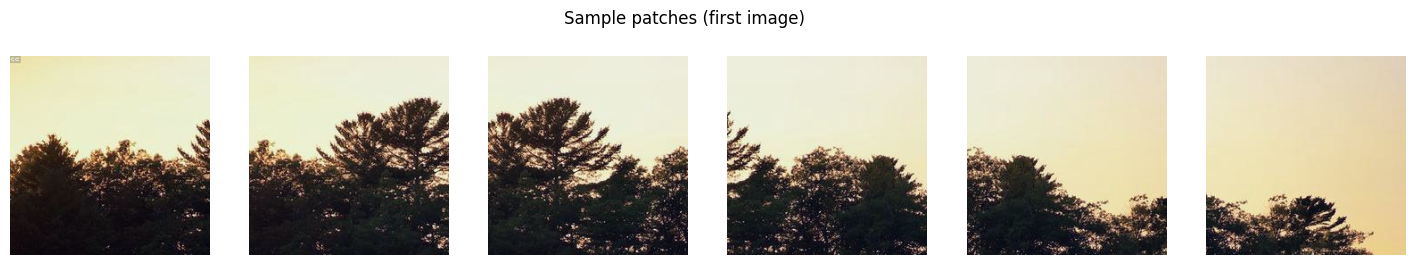

In [77]:
batch = next(iter(train_dl))
patches0 = batch["patches"][0]   # [N,3,P,P]
print("patch tensor:", patches0.shape)

k = min(6, patches0.shape[0])
fig, axes = plt.subplots(1, k, figsize=(3*k, 3))
for i in range(k):
    img = patches0[i].numpy().transpose(1,2,0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    axes[i].imshow(img)
    axes[i].axis("off")
plt.suptitle("Sample patches (first image)")
plt.show()


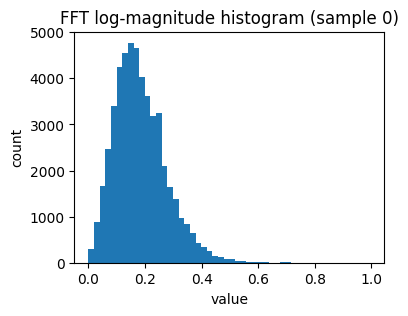

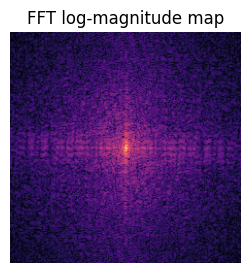

In [78]:
fft0 = batch["fft"][0].squeeze(0).numpy()

plt.figure(figsize=(4,3))
plt.hist(fft0.flatten(), bins=50)
plt.title("FFT log-magnitude histogram (sample 0)")
plt.xlabel("value"); plt.ylabel("count")
plt.show()

plt.figure(figsize=(3,3))
plt.imshow(fft0, cmap="magma")
plt.title("FFT log-magnitude map")
plt.axis("off")
plt.show()


In [79]:
# ---- FFT baseline: model + helpers ----
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

class FFTProbe(nn.Module):
    """
    Tiny MLP (or logistic if hidden=None) over flattened FFT tensor [B,1,P,P].
    """
    def __init__(self, in_hw, hidden=128):
        super().__init__()
        c, h, w = in_hw
        in_dim = c * h * w
        if hidden is None:
            self.net = nn.Linear(in_dim, 1)  # logistic regression
        else:
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, 1)
            )
        self.flatten = nn.Flatten()

    def forward(self, x):  # x: [B,1,P,P]
        z = self.flatten(x)
        return self.net(z).squeeze(1)  # logits

@torch.no_grad()
def evaluate_fft(model, loader, device=DEVICE):
    model.eval()
    all_logits, all_y = [], []
    for b in loader:
        x = b["fft"].to(device).float()      # [B,1,P,P]
        y = b["labels"].to(device).float()   # [B]
        logits = model(x)
        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())
    if not all_logits:
        return {"acc": np.nan, "auroc": np.nan, "cm": np.array([[0,0],[0,0]])}
    logits = torch.cat(all_logits).numpy()
    ytrue  = torch.cat(all_y).numpy()

    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(ytrue, preds)
    try:
        auroc = roc_auc_score(ytrue, probs)
    except Exception:
        auroc = float("nan")
    cm = confusion_matrix(ytrue, preds, labels=[0,1])
    return {"acc": acc, "auroc": auroc, "cm": cm, "probs": probs, "preds": preds, "ytrue": ytrue}

def plot_confusion(cm, title="Confusion matrix"):
    fig, ax = plt.subplots(figsize=(3.2,3.2))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["real(0)","fake(1)"])
    ax.set_yticklabels(["real(0)","fake(1)"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for (i,j), v in np.ndenumerate(cm):
        ax.text(j, i, int(v), ha="center", va="center")
    plt.show()


ep 01 | train acc=0.500 auroc=1.000 | val acc=0.500 auroc=1.000
ep 02 | train acc=0.500 auroc=1.000 | val acc=0.500 auroc=1.000
ep 03 | train acc=0.500 auroc=0.500 | val acc=0.500 auroc=0.000
ep 04 | train acc=0.500 auroc=0.625 | val acc=0.500 auroc=0.000
ep 05 | train acc=1.000 auroc=1.000 | val acc=0.500 auroc=0.500
ep 06 | train acc=0.500 auroc=1.000 | val acc=0.500 auroc=1.000
ep 07 | train acc=0.500 auroc=1.000 | val acc=0.500 auroc=1.000
ep 08 | train acc=0.500 auroc=1.000 | val acc=0.500 auroc=1.000

Final (VAL @ 0.5):
Accuracy : 0.500
AUROC    : 1.000
Confusion:
 [[2 0]
 [2 0]]


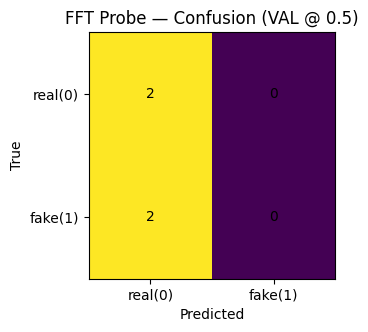

In [82]:
# ---- Train/eval loop for FFT baseline ----
# infer FFT size P from one batch
tmp_batch = next(iter(train_dl))
P = tmp_batch["fft"].shape[-1]

# logistic probe (good for tiny data); set hidden=128 to use a 1-layer MLP
fft_model = FFTProbe(in_hw=(1, P, P), hidden=None).to(DEVICE)

opt = torch.optim.AdamW(fft_model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 8

for ep in range(1, EPOCHS + 1):
    fft_model.train()
    for b in train_dl:
        x = b["fft"].to(DEVICE).float()      # [B,1,P,P]
        y = b["labels"].to(DEVICE).float()   # [B]
        logits = fft_model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()

    tr = evaluate_fft(fft_model, train_dl, DEVICE)
    va = evaluate_fft(fft_model, val_dl,   DEVICE)
    print(f"ep {ep:02d} | "
          f"train acc={tr['acc']:.3f} auroc={tr['auroc']:.3f} | "
          f"val acc={va['acc']:.3f} auroc={va['auroc']:.3f}")

# Final quick report (fixed 0.5 threshold) + confusion matrix
final_val = evaluate_fft(fft_model, val_dl, DEVICE)
print("\nFinal (VAL @ 0.5):")
print("Accuracy :", f"{final_val['acc']:.3f}")
print("AUROC    :", f"{final_val['auroc']:.3f}")
print("Confusion:\n", final_val["cm"])
plot_confusion(final_val["cm"], title="FFT Probe — Confusion (VAL @ 0.5)")




Chosen τ=0.0748  (TPR=1.000, FPR=0.000)
VAL Accuracy: 1.000
VAL Confusion:
 [[2 0]
 [0 2]]


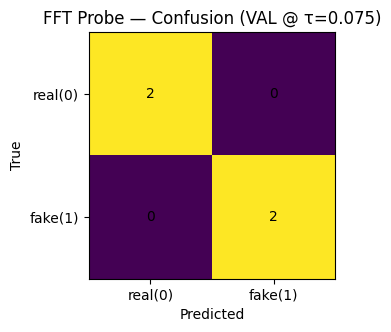

In [83]:
# ---- Threshold selection from ROC + recompute metrics ----
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix
import numpy as np

def pick_threshold(y_true, prob, mode="youden", target_fpr=0.05):
    """
    mode='youden': maximize (TPR - FPR) on ROC (balanced operating point)
    mode='target_fpr': choose the largest threshold with FPR <= target_fpr
    """
    fpr, tpr, thr = roc_curve(y_true, prob)
    if mode == "youden":
        j = tpr - fpr
        i = int(np.argmax(j))
        return float(thr[i]), float(tpr[i]), float(fpr[i])
    elif mode == "target_fpr":
        mask = fpr <= target_fpr
        i = int(np.where(mask)[0][-1]) if mask.any() else 0
        return float(thr[i]), float(tpr[i]), float(fpr[i])
    else:
        raise ValueError("mode must be 'youden' or 'target_fpr'")

va = evaluate_fft(fft_model, val_dl, DEVICE)

# choose threshold: try Youden; for product targets use 'target_fpr'
tau, tpr, fpr = pick_threshold(va["ytrue"], va["probs"], mode="youden")  # or mode="target_fpr", target_fpr=0.05
preds = (va["probs"] >= tau).astype(int)

acc = accuracy_score(va["ytrue"], preds)
cm  = confusion_matrix(va["ytrue"], preds, labels=[0,1])

print(f"Chosen τ={tau:.4f}  (TPR={tpr:.3f}, FPR={fpr:.3f})")
print("VAL Accuracy:", f"{acc:.3f}")
print("VAL Confusion:\n", cm)
plot_confusion(cm, title=f"FFT Probe — Confusion (VAL @ τ={tau:.3f})")


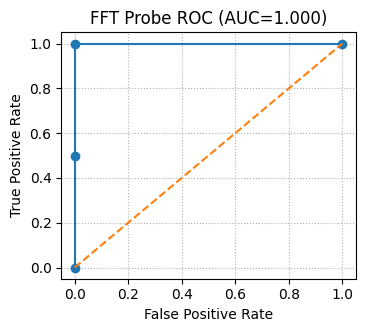

VAL TPR@1%FPR: 1.000
VAL TPR@5%FPR: 1.000


In [84]:
# ---- ROC curve + TPR@FPR readouts ----
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thr = roc_curve(va["ytrue"], va["probs"])
auc = roc_auc_score(va["ytrue"], va["probs"])

plt.figure(figsize=(3.8,3.2))
plt.plot(fpr, tpr, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"FFT Probe ROC (AUC={auc:.3f})")
plt.grid(True, ls=":")
plt.show()

def tpr_at_fpr(y_true, prob, target_fpr=0.05):
    fpr, tpr, _ = roc_curve(y_true, prob)
    mask = fpr <= target_fpr
    return float(tpr[mask].max()) if mask.any() else 0.0

print("VAL TPR@1%FPR:", f"{tpr_at_fpr(va['ytrue'], va['probs'], 0.01):.3f}")
print("VAL TPR@5%FPR:", f"{tpr_at_fpr(va['ytrue'], va['probs'], 0.05):.3f}")


**FFT-only baseline (smoke set)**
- Split: stratified (2 val per class)
- Model: logistic over flattened FFT (P=224)
- AUC: 1.00 (toy set)
- Threshold: τ=0.075 (Youden) → VAL acc=1.00, FPR=0.00, TPR=1.00
- Note: numbers are unstable on N=4 val; goal here is pipeline sanity & evidence that frequency features carry signal.
